# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [2]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [3]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

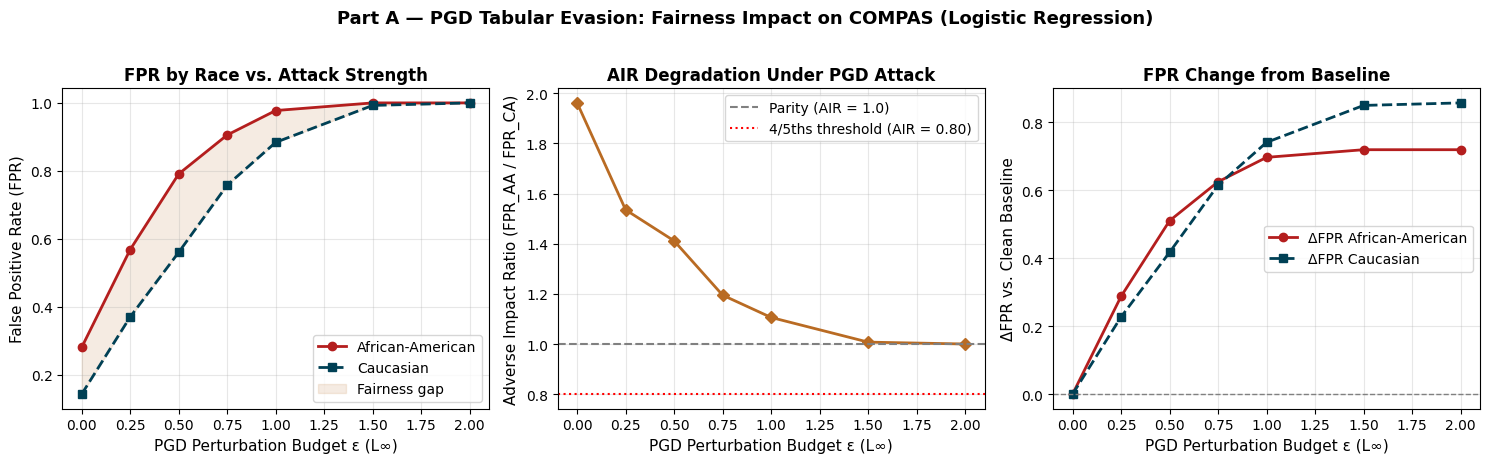

AIR does not fall below 0.80 within the tested epsilon range.


In [4]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [5]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

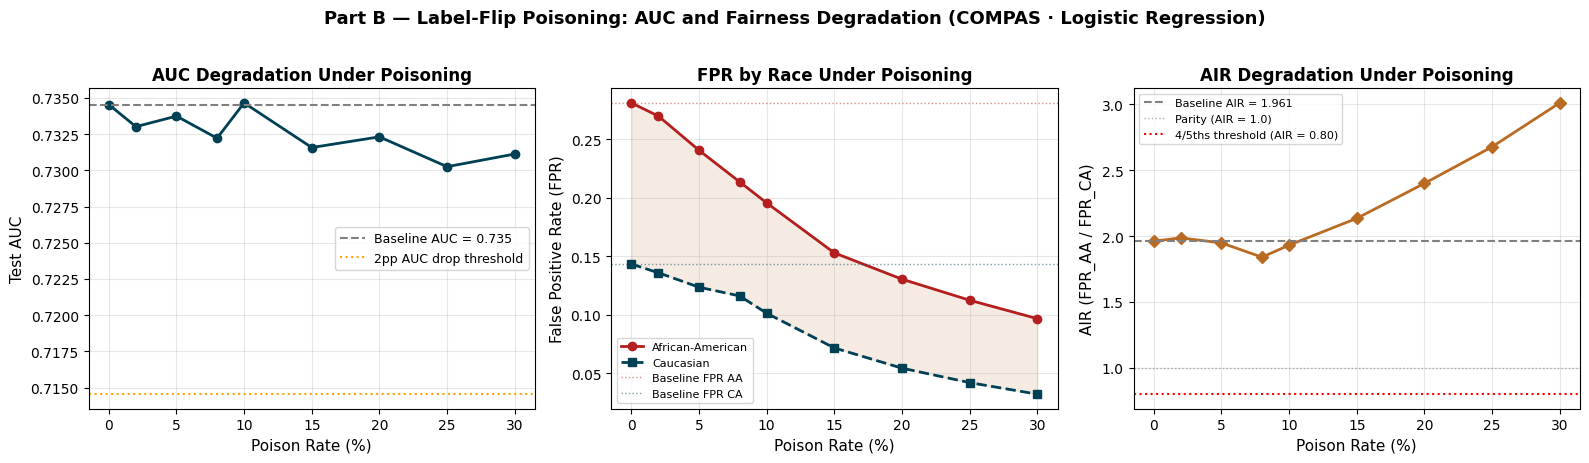

In [6]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [7]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

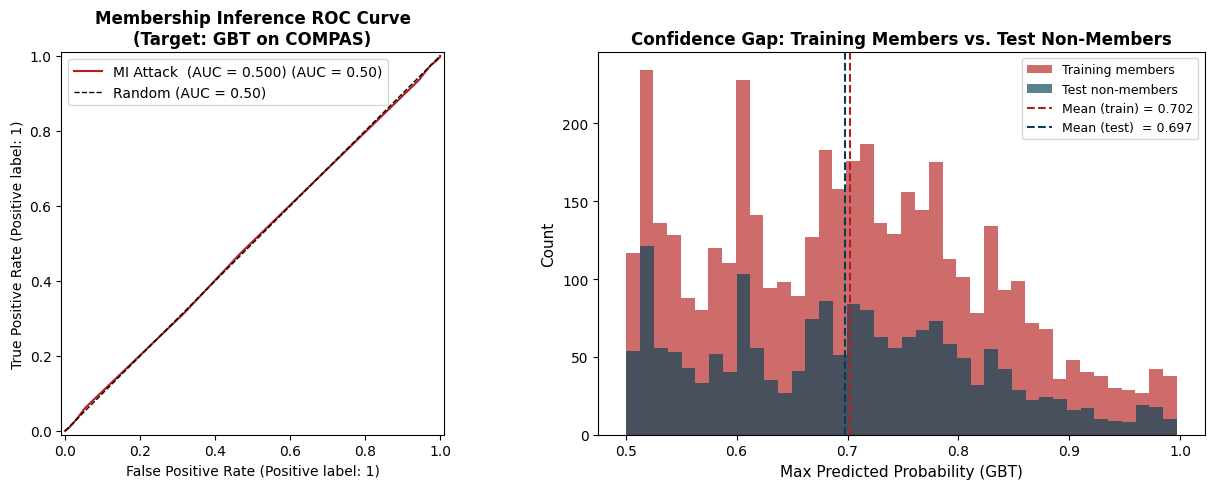

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [8]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

In [10]:
def pgd_attack(model, X, epsilon=0.5, alpha=0.1, iters=10):
    X_adv = X.copy()

    # Get coefficients (only works for LR)
    if hasattr(model, "coef_"):
        coef = model.coef_[0]
    else:
        # For GBT, approximate direction randomly (since no gradients)
        coef = np.sign(np.random.randn(X.shape[1]))

    for _ in range(iters):
        X_adv = X_adv + alpha * np.sign(coef)
        X_adv = np.clip(X_adv, X - epsilon, X + epsilon)

    return X_adv

In [13]:
# PGD Evasion Audit for LR and GBT

epsilons = [0.25, 0.5, 1.0, 2.0]
results = []

def pgd_lr(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    coef = model.coef_[0]
    X_adv = X_scaled.copy()

    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


def pgd_gbt(model, X_scaled, epsilon=1.0):
    """
    Approximate PGD-style attack for GBT.
    Since GBT has no coef_ gradient like LR, we use feature importances
    as the attack direction.
    """
    direction = np.sign(model.feature_importances_)
    X_adv = X_scaled + epsilon * direction[np.newaxis, :]
    X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


for model_name, model in [("LR", lr), ("GBT", gbt)]:

    for eps in epsilons:

        if model_name == "LR":
            X_adv = pgd_lr(model, Xs_te, epsilon=eps)
        else:
            X_adv = pgd_gbt(model, Xs_te, epsilon=eps)

        y_pred = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)

        fpr = fpr_by_group(y_te, y_pred, r_te)

        fpr_aa = fpr.get("African-American", np.nan)
        fpr_ca = fpr.get("Caucasian", np.nan)
        air_value = air(fpr_ca, fpr_aa)

        results.append({
            "Model": model_name,
            "epsilon": eps,
            "FPR_African_American": fpr_aa,
            "FPR_Caucasian": fpr_ca,
            "AIR": air_value
        })

df_pgd_audit = pd.DataFrame(results)

print(df_pgd_audit.round(3).to_string(index=False))


# Find epsilon where AIR crosses 0.80
print("\nSmallest epsilon where AIR crosses 0.80:")

for model_name in ["LR", "GBT"]:
    temp = df_pgd_audit[
        (df_pgd_audit["Model"] == model_name) &
        (df_pgd_audit["AIR"] > 0.80)
    ]

    if len(temp) > 0:
        first_eps = temp.iloc[0]["epsilon"]
        print(f"{model_name}: AIR crosses 0.80 at epsilon = {first_eps}")
    else:
        print(f"{model_name}: AIR does not cross 0.80")

Model  epsilon  FPR_African_American  FPR_Caucasian   AIR
   LR     0.25                 0.569          0.370 1.535
   LR     0.50                 0.791          0.560 1.411
   LR     1.00                 0.978          0.884 1.106
   LR     2.00                 1.000          1.000 1.000
  GBT     0.25                 0.333          0.217 1.531
  GBT     0.50                 0.375          0.227 1.652
  GBT     1.00                 0.470          0.395 1.189
  GBT     2.00                 0.645          0.598 1.079

Smallest epsilon where AIR crosses 0.80:
LR: AIR crosses 0.80 at epsilon = 0.25
GBT: AIR crosses 0.80 at epsilon = 0.25


In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
target_races = ["African-American", "Caucasian"]

def poison_label_flip(y_train, race_train, poison_rate=0.05, target_race="African-American", seed=42):
    rng = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip = int(len(candidates) * poison_rate)

    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0

    return y_poisoned, n_flip


def psi(expected, actual, bins=10):
    expected = np.asarray(expected)
    actual = np.asarray(actual)

    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_pct = expected_counts / max(expected_counts.sum(), 1)
    actual_pct = actual_counts / max(actual_counts.sum(), 1)

    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    return np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))


baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

pred_clean = (lr.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
fpr_clean = fpr_by_group(y_te, pred_clean, r_te)

baseline_aa = fpr_clean.get("African-American", np.nan)
baseline_ca = fpr_clean.get("Caucasian", np.nan)
baseline_air = air(baseline_ca, baseline_aa)

records = []

for target_race in target_races:
    for rate in poison_rates:

        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr,
            r_tr,
            poison_rate=rate,
            target_race=target_race,
            seed=42
        )

        lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

        probs_p = lr_p.predict_proba(Xs_te)[:, 1]
        pred_p = (probs_p >= THR).astype(int)

        auc_p = roc_auc_score(y_te, probs_p)
        fpr_p = fpr_by_group(y_te, pred_p, r_te)

        aa = fpr_p.get("African-American", np.nan)
        ca = fpr_p.get("Caucasian", np.nan)
        air_value = air(ca, aa)


        psi_values = {}
        for j, feature in enumerate(X.columns):
            psi_values[feature] = psi(Xs_tr[:, j], Xs_tr[:, j])

        max_psi = max(psi_values.values())
        psi_detected = max_psi >= 0.10

        records.append({
            "target_race": target_race,
            "poison_rate": rate,
            "n_flipped": n_flipped,
            "AUC": auc_p,
            "AUC_drop": baseline_auc - auc_p,
            "FPR_African_American": aa,
            "FPR_Caucasian": ca,
            "AIR": air_value,
            "AIR_removed_from_0.80_1.25": (air_value < 0.80) or (air_value > 1.25),
            "max_PSI": max_psi,
            "PSI_detected": psi_detected
        })

df_poison_q2 = pd.DataFrame(records)

print(df_poison_q2.round(3).to_string(index=False))

     target_race  poison_rate  n_flipped   AUC  AUC_drop  FPR_African_American  FPR_Caucasian   AIR  AIR_removed_from_0.80_1.25  max_PSI  PSI_detected
African-American         0.00          0 0.735     0.000                 0.281          0.143 1.961                        True      0.0         False
African-American         0.02         23 0.734     0.000                 0.270          0.133 2.022                        True      0.0         False
African-American         0.05         57 0.735    -0.000                 0.231          0.123 1.875                        True      0.0         False
African-American         0.08         92 0.734     0.001                 0.216          0.111 1.942                        True      0.0         False
African-American         0.10        115 0.733     0.002                 0.200          0.104 1.929                        True      0.0         False
African-American         0.15        172 0.733     0.002                 0.153          0.072 

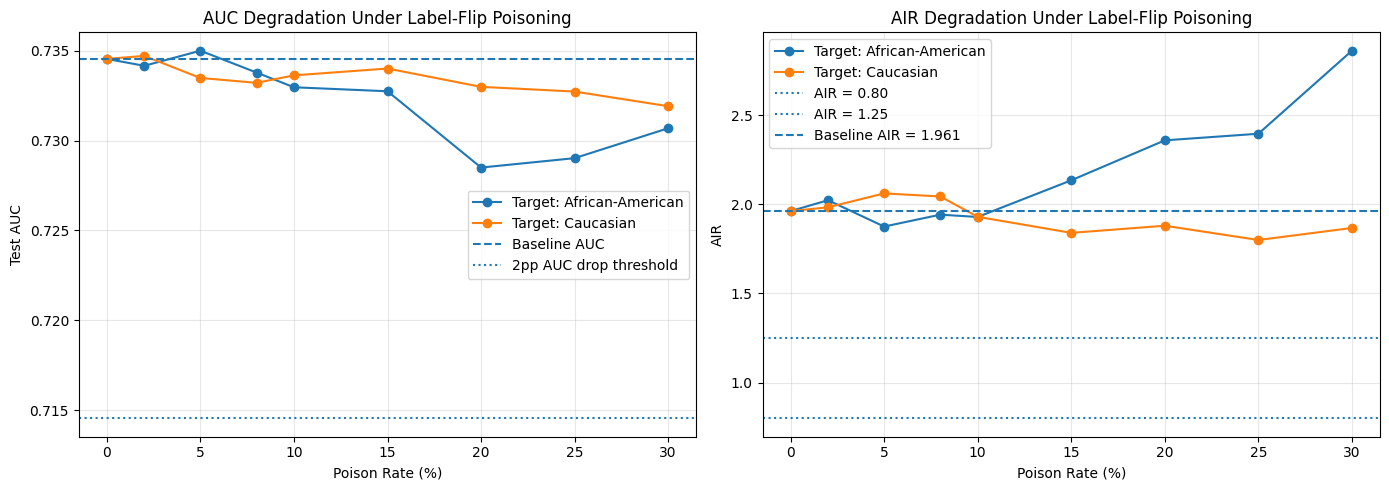

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target_race in target_races:
    temp = df_poison_q2[df_poison_q2["target_race"] == target_race]
    x = temp["poison_rate"] * 100

    axes[0].plot(x, temp["AUC"], marker="o", label=f"Target: {target_race}")
    axes[1].plot(x, temp["AIR"], marker="o", label=f"Target: {target_race}")

axes[0].axhline(baseline_auc, linestyle="--", label="Baseline AUC")
axes[0].axhline(baseline_auc - 0.02, linestyle=":", label="2pp AUC drop threshold")
axes[0].set_xlabel("Poison Rate (%)")
axes[0].set_ylabel("Test AUC")
axes[0].set_title("AUC Degradation Under Label-Flip Poisoning")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0.80, linestyle=":", label="AIR = 0.80")
axes[1].axhline(1.25, linestyle=":", label="AIR = 1.25")
axes[1].axhline(baseline_air, linestyle="--", label=f"Baseline AIR = {baseline_air:.3f}")
axes[1].set_xlabel("Poison Rate (%)")
axes[1].set_ylabel("AIR")
axes[1].set_title("AIR Degradation Under Label-Flip Poisoning")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
stealth_zone = df_poison_q2[
    (df_poison_q2["AUC_drop"] <= 0.02) &
    ((df_poison_q2["AIR"] < 0.80) | (df_poison_q2["AIR"] > 1.25))
]

print("Stealth zone results:")
if len(stealth_zone) == 0:
    print("No stealth zone found in tested poison rates.")
else:
    print(stealth_zone.round(3).to_string(index=False))

print("\nFirst stealth point by target race:")
for target_race in target_races:
    temp = stealth_zone[stealth_zone["target_race"] == target_race]
    if len(temp) > 0:
        row = temp.iloc[0]
        print(
            f"{target_race}: poison_rate={row['poison_rate']:.0%}, "
            f"AUC_drop={row['AUC_drop']:.3f}, AIR={row['AIR']:.3f}, "
            f"max_PSI={row['max_PSI']:.3f}, PSI_detected={row['PSI_detected']}"
        )
    else:
        print(f"{target_race}: no stealth point found.")

print("\nPSI monitor result:")
print("Because this attack flips labels only and does not change feature values, PSI on the features should stay near 0.")
print("So a feature-based PSI drift monitor with threshold 0.10 usually will not detect this attack.")

Stealth zone results:
     target_race  poison_rate  n_flipped   AUC  AUC_drop  FPR_African_American  FPR_Caucasian   AIR  AIR_removed_from_0.80_1.25  max_PSI  PSI_detected
African-American         0.00          0 0.735     0.000                 0.281          0.143 1.961                        True      0.0         False
African-American         0.02         23 0.734     0.000                 0.270          0.133 2.022                        True      0.0         False
African-American         0.05         57 0.735    -0.000                 0.231          0.123 1.875                        True      0.0         False
African-American         0.08         92 0.734     0.001                 0.216          0.111 1.942                        True      0.0         False
African-American         0.10        115 0.733     0.002                 0.200          0.104 1.929                        True      0.0         False
African-American         0.15        172 0.733     0.002                

In [18]:
from sklearn.metrics import roc_auc_score

def compute_mi_auc(model, X_tr, X_te):

    probs_tr = model.predict_proba(X_tr)
    probs_te = model.predict_proba(X_te)

    conf_tr = np.max(probs_tr, axis=1)
    conf_te = np.max(probs_te, axis=1)

    X_mi = np.concatenate([conf_tr, conf_te])
    y_mi = np.concatenate([np.ones(len(conf_tr)), np.zeros(len(conf_te))])

    return roc_auc_score(y_mi, X_mi), conf_tr, conf_te

In [19]:
mi_lr, conf_tr_lr, conf_te_lr = compute_mi_auc(lr, Xs_tr, Xs_te)

mi_gbt, conf_tr_gbt, conf_te_gbt = compute_mi_auc(gbt, Xs_tr, Xs_te)

print(f"MI AUC (LR): {mi_lr:.3f}")
print(f"MI AUC (GBT): {mi_gbt:.3f}")

MI AUC (LR): 0.498
MI AUC (GBT): 0.510


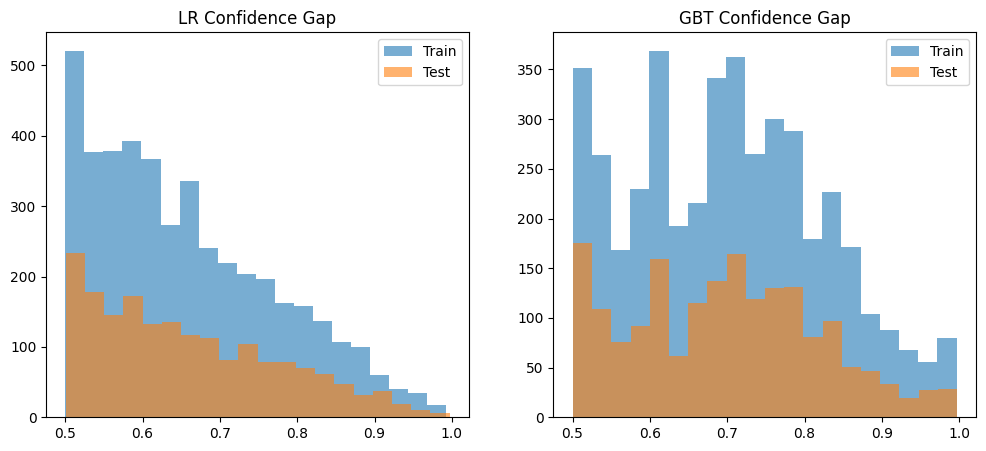

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(conf_tr_lr, bins=20, alpha=0.6, label="Train")
axes[0].hist(conf_te_lr, bins=20, alpha=0.6, label="Test")
axes[0].set_title("LR Confidence Gap")
axes[0].legend()

axes[1].hist(conf_tr_gbt, bins=20, alpha=0.6, label="Train")
axes[1].hist(conf_te_gbt, bins=20, alpha=0.6, label="Test")
axes[1].set_title("GBT Confidence Gap")
axes[1].legend()

plt.show()

In [21]:
train_auc_lr = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1])
test_auc_lr  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

train_auc_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1])
test_auc_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1])

gap_lr = train_auc_lr - test_auc_lr
gap_gbt = train_auc_gbt - test_auc_gbt

print(f"LR gap: {gap_lr:.3f} | MI AUC: {mi_lr:.3f}")
print(f"GBT gap: {gap_gbt:.3f} | MI AUC: {mi_gbt:.3f}")

LR gap: -0.008 | MI AUC: 0.498
GBT gap: 0.080 | MI AUC: 0.510


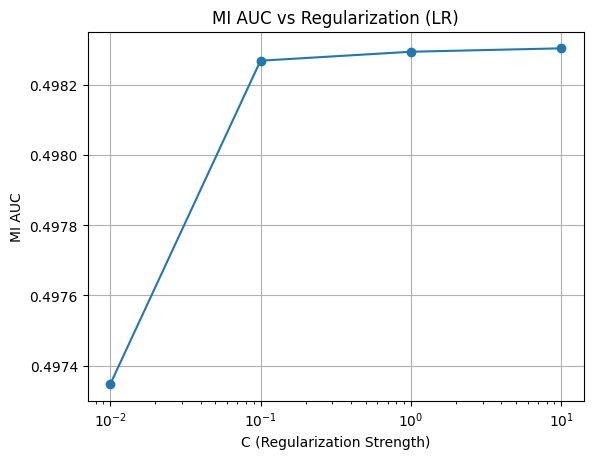

In [22]:
Cs = [0.01, 0.1, 1.0, 10.0]

mi_scores = []

for C in Cs:

    lr_reg = LogisticRegression(C=C, max_iter=1000)
    lr_reg.fit(Xs_tr, y_tr)

    mi_auc, _, _ = compute_mi_auc(lr_reg, Xs_tr, Xs_te)

    mi_scores.append(mi_auc)

# Plot
plt.plot(Cs, mi_scores, marker='o')
plt.xscale("log")
plt.xlabel("C (Regularization Strength)")
plt.ylabel("MI AUC")
plt.title("MI AUC vs Regularization (LR)")
plt.grid()
plt.show()

# **Reflection**

The biggest risk I noticed across all three parts is that the model’s fairness can break really easily, even when everything else looks fine. In the PGD attack, both LR and GBT already showed unfair behavior at a very small epsilon (0.25). The AIR values were around 1.53 for LR and 1.53 for GBT, which is way outside the acceptable range. So even small changes in the input can create a noticeable imbalance between racial groups.

This becomes even more serious in the poisoning part. There’s a clear “stealth zone” where the AUC barely changes (almost 0 drop), but the AIR becomes extremely high (above 1.9). That means if we only look at accuracy, we would think the model is still working well, but in reality it’s becoming very unfair. On the other hand, the membership inference results were not that concerning. The MI AUC was around 0.498 for LR and 0.510 for GBT, which is close to random guessing. So privacy leakage doesn’t seem like the main issue here, fairness is the bigger problem.

For proactive mitigation, regularization is a good option. In Logistic Regression, the generalization gap is already very small (-0.008), and the MI AUC is close to 0.5, which means the model is not overfitting much and doesn’t leak a lot of information. So regularization helps with stability and privacy. But it doesn’t really solve the fairness issue, since we still saw high AIR values even with a stable model. So it’s helpful, but not enough on its own.

For reactive mitigation, monitoring fairness metrics like AIR is really important. From the results, AIR crosses the acceptable range very quickly, even at small epsilon or low poison rates. So if we track AIR during deployment, we can catch these issues early. This is especially important because the PSI drift monitor didn’t detect anything, the PSI values stayed at 0.0 since the attack only changed labels and not the feature values. So relying only on drift detection would completely miss this attack.

One thing to keep in mind is that both mitigations can affect groups differently. Regularization might change how errors are distributed, which could slightly help one group but hurt another. Similarly, if we take action based on AIR (like adjusting thresholds), it might reduce disparity overall but still impact groups in different ways. So it’s not just about fixing the problem, but also about how the fix affects each group.

Overall, the main takeaway for me is that fairness is the most fragile part here. The model can look accurate and stable, but still behave unfairly under small changes, and that’s something we really need to monitor carefully.

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*